<a href="https://colab.research.google.com/github/jananiksaagash-rgb/AppliedAI/blob/main/Ex10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-03-30 142045.png to Screenshot 2026-03-30 142045 (1).png


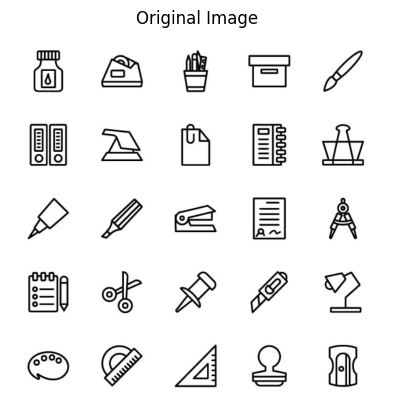

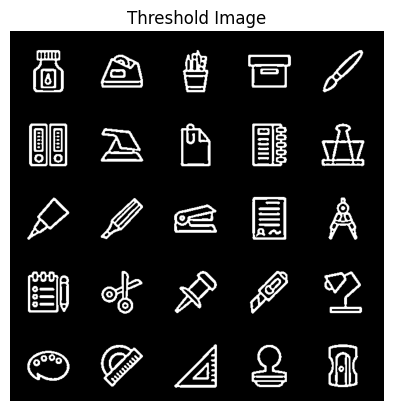

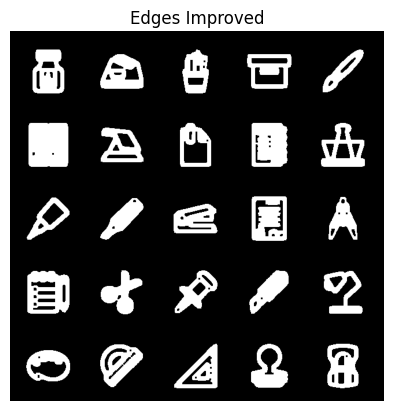

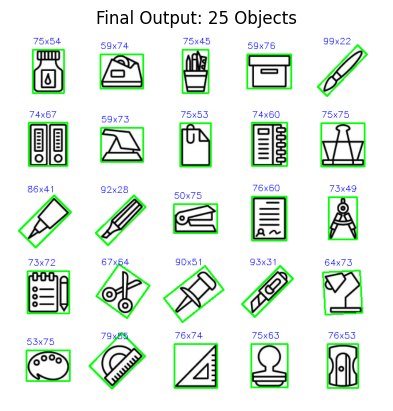

Total objects detected: 25
Latency: 0.002 seconds


In [8]:
# Install
!pip install imutils -q
# Imports
import cv2
import numpy as np
import imutils
import time
from matplotlib import pyplot as plt
from google.colab import files

#  Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

#  Load Image
image = cv2.imread(image_path)
orig = image.copy()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

#  Grayscale + Blur
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (9, 9), 0)

# Threshold
thresh = cv2.adaptiveThreshold(
    blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 11, 2)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

#  Edge Detection
edged = cv2.Canny(blur, 30, 150)

kernel = np.ones((3,3), np.uint8)
edged = cv2.dilate(edged, kernel, iterations=2)
edged = cv2.erode(edged, kernel, iterations=1)

plt.imshow(edged, cmap='gray')
plt.title("Edges Improved")
plt.axis("off")
plt.show()

#  Find Contours
cnts = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

#  Measurement + Counting
object_count = 0
start_time = time.time()

for c in cnts:
    if cv2.contourArea(c) < 20:
        continue

    object_count += 1

    rect = cv2.minAreaRect(c)
    box = cv2.boxPoints(rect)
    box = np.intp(box)

    cv2.drawContours(image, [box], -1, (0, 255, 0), 2)

    w, h = rect[1]
    x, y, bw, bh = cv2.boundingRect(c)

    label = f"{int(w)}x{int(h)}"

    cv2.putText(image, label,
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                (255, 0, 0), 1)

#  Latency (ONLY calculated, not shown on image)
end_time = time.time()
latency = end_time - start_time

#  Final Output Image (NO count/latency text)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title(f"Final Output: {object_count} Objects")
plt.axis("off")
plt.show()

# Console Output ONLY
print(f"Total objects detected: {object_count}")
print(f"Latency: {latency:.3f} seconds")